# Main V8 — Within-Patient vs Cross-Patient Evaluation

## Motivation

Most published papers reporting AUC > 0.85 on CHB-MIT use **within-patient
(personalized) models**: they train and test on the **same patient** using a
temporal split, not a cross-patient leave-one-patient-out (LOPO) protocol.

V8 quantifies this methodological gap directly:

| Protocol | Training data | Expected AUC |
|---|---|---|
| **Cross-patient LOPO** (V3–V6) | All OTHER patients | ~0.54–0.57 |
| **Within-patient** (this notebook) | Same patient (first 70%) | ~ literature |

Both use the **same V6 PDC features** (reused from `cache_pdc_var20/` cache).
No feature recomputation — within-patient just changes the training/test split.

## Within-patient split strategy

For each patient with windows in temporal order (features extracted from sequential
EDF files):
- Find the index of the first preictal window in the **last 30%** of preictal windows
- Use all windows before that index as **training**
- Use all windows from that index onward as **test**

This guarantees: (1) temporal ordering preserved, (2) test always has preictal windows.


In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# Cell 0 — Imports & load V6 PDC features

import os, sys, json, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS, FS,
    WINDOW_SEC, STEP_SEC, EXCLUDED_PATIENTS, RESULTS_DIR,
    INTERICTAL_MULTIPLIER, MAX_INTERICTAL_ABS, RANDOM_SEED,
)
from summary_parser import parse_all_summaries

from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (roc_auc_score, average_precision_score,
                                       roc_curve)

np.random.seed(RANDOM_SEED)

PDC_CACHE_DIR = os.path.join(CODE_DIR, 'cache_pdc_var20')
BAND_NAMES    = ['delta', 'theta', 'alpha', 'beta']
FEATS_PER_BAND = 67
N_FEATS       = len(BAND_NAMES) * FEATS_PER_BAND   # 268


# ── Load V6 PDC features (no recomputation) ───────────────────────────────
pdc_raw = {}

patients_all = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb') and p not in EXCLUDED_PATIENTS
])

for pid in patients_all:
    feat_p = Path(PDC_CACHE_DIR) / pid / 'features.npy'
    lab_p  = Path(PDC_CACHE_DIR) / pid / 'labels.npy'
    if not feat_p.exists():
        continue
    X = np.load(str(feat_p)); y = np.load(str(lab_p))
    if (y == 1).sum() == 0:
        continue
    pdc_raw[pid] = (X, y)
    print(f'  {pid}: {X.shape}  pre={(y==1).sum()}  int={(y==0).sum()}')

print(f'\nLoaded {len(pdc_raw)} patients  |  features shape: 268 (4 bands × 67)')


  chb01: (1333, 268)  pre=296  int=1037
  chb02: (635, 268)  pre=296  int=339
  chb03: (1343, 268)  pre=444  int=899
  chb04: (3072, 268)  pre=296  int=2776
  chb05: (1026, 268)  pre=444  int=582
  chb06: (7717, 268)  pre=1037  int=6680
  chb07: (2933, 268)  pre=445  int=2488
  chb08: (1276, 268)  pre=741  int=535
  chb09: (2823, 268)  pre=592  int=2231
  chb10: (3950, 268)  pre=888  int=3062
  chb13: (1391, 268)  pre=444  int=947
  chb14: (1461, 268)  pre=774  int=687
  chb15: (2282, 268)  pre=320  int=1962
  chb16: (840, 268)  pre=347  int=493
  chb17: (828, 268)  pre=444  int=384
  chb18: (1291, 268)  pre=592  int=699
  chb19: (771, 268)  pre=296  int=475
  chb20: (905, 268)  pre=369  int=536
  chb22: (809, 268)  pre=296  int=513
  chb23: (1990, 268)  pre=608  int=1382
  chb24: (2623, 268)  pre=939  int=1684

Loaded 21 patients  |  features shape: 268 (4 bands × 67)


## 1 · Apply interictal cap

In [2]:
# Cell 1 — Apply interictal cap (same parameters as V6)

pdc_data = {}

for pid, (X, y) in pdc_raw.items():
    n_pre = int((y == 1).sum())
    cap   = min(int((y == 0).sum()), INTERICTAL_MULTIPLIER * n_pre, MAX_INTERICTAL_ABS)
    if int((y == 0).sum()) > cap:
        rng  = np.random.default_rng(RANDOM_SEED + hash(pid) % 10_000)
        keep = np.sort(np.concatenate([
            np.where(y == 1)[0],
            rng.choice(np.where(y == 0)[0], size=cap, replace=False)
        ]))
        X, y = X[keep], y[keep]
    pdc_data[pid] = (X, y)

patient_ids = sorted(pdc_data.keys())
print(f'{len(patient_ids)} patients ready.')
print(f'Total preictal   : {sum(int((y==1).sum()) for _,(_, y) in pdc_data.items()):,}')
print(f'Total interictal : {sum(int((y==0).sum()) for _,(_, y) in pdc_data.items()):,}')


21 patients ready.
Total preictal   : 10,908
Total interictal : 26,790


## 2 · Within-patient evaluation

In [3]:
# Cell 2 — Within-patient temporal split and model fitting

def within_patient_split(X, y, test_preictal_frac=0.30, min_test_pre=2):
    """
    Temporally split (X, y) so that the last `test_preictal_frac` fraction
    of preictal windows go to the test set, along with all subsequent windows.

    Returns (X_train, y_train, X_test, y_test) or (None,)*4 if infeasible.
    """
    pre_idx = np.where(y == 1)[0]
    if len(pre_idx) < min_test_pre + 1:
        return None, None, None, None

    n_test_pre = max(min_test_pre, int(len(pre_idx) * test_preictal_frac))
    n_test_pre = min(n_test_pre, len(pre_idx) - 1)   # keep ≥1 in train

    split_at = int(pre_idx[-n_test_pre])   # temporal split point

    Xtr, ytr = X[:split_at], y[:split_at]
    Xte, yte = X[split_at:], y[split_at:]

    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        return None, None, None, None

    return Xtr, ytr, Xte, yte


from seizure_metrics import generate_alarms, false_alarms_per_hour
from config import ALARM_K, ALARM_M, ALARM_REFRACTORY, STEP_SEC

def evaluate_fold(probs, y_te, n_int_hours):
    if len(np.unique(y_te)) < 2:
        return None
    auc    = roc_auc_score(y_te, probs)
    auc_pr = average_precision_score(y_te, probs)
    fpr, tpr, thr = roc_curve(y_te, probs)
    t    = float(thr[np.argmax(tpr - fpr)])
    pred = (probs >= t).astype(int)
    tp = int(((pred==1)&(y_te==1)).sum()); fp = int(((pred==1)&(y_te==0)).sum())
    tn = int(((pred==0)&(y_te==0)).sum()); fn = int(((pred==0)&(y_te==1)).sum())
    sens = tp/max(tp+fn,1); spec = tn/max(tn+fp,1); prec = tp/max(tp+fp,1)
    return dict(auc=auc, auc_pr=auc_pr, sensitivity=sens, specificity=spec,
                precision=prec, f1=2*prec*sens/max(prec+sens,1e-9),
                balanced_accuracy=0.5*(sens+spec),
                fpr_per_hour=false_alarms_per_hour(generate_alarms(pred.astype(float), 0.5, ALARM_K, ALARM_M, ALARM_REFRACTORY), y_te, STEP_SEC))


METRIC_KEYS = ['auc','auc_pr','sensitivity','specificity',
               'precision','f1','balanced_accuracy','fpr_per_hour']

print('Within-patient split and evaluation functions defined.')


Within-patient split and evaluation functions defined.


In [4]:
# Cell 3 — Run within-patient models (LR + SVM) for all patients

models = {
    'LR': Pipeline([('scl', StandardScaler()),
                    ('clf', LogisticRegression(max_iter=400, solver='lbfgs',
                        class_weight='balanced', C=1.0,
                        random_state=RANDOM_SEED))]),
    'SVM': Pipeline([('scl', StandardScaler()),
                     ('clf', SVC(kernel='rbf', class_weight='balanced',
                         C=1.0, probability=True, random_state=RANDOM_SEED))]),
}

within_results = {name: [] for name in models}
skipped = []

print(f'Within-patient evaluation  ({len(patient_ids)} patients)')
print(f'Split: last 30% of preictal windows → test, rest → train\n')

for pid in patient_ids:
    X, y = pdc_data[pid]
    Xtr, ytr, Xte, yte = within_patient_split(X, y)

    if Xtr is None:
        skipped.append(pid)
        print(f'  SKIP {pid}: insufficient preictal windows for split')
        continue

    n_int_hours = (yte == 0).sum() * STEP_SEC / 3600.

    for mname, pipe in models.items():
        pipe.fit(Xtr, ytr)
        probs = pipe.predict_proba(Xte)[:, 1]
        m = evaluate_fold(probs, yte, n_int_hours)
        if m:
            m['patient'] = pid
            within_results[mname].append(m)

    lr_row  = next((r for r in within_results['LR']  if r['patient'] == pid), None)
    svm_row = next((r for r in within_results['SVM'] if r['patient'] == pid), None)
    lr_pr   = f'{lr_row["auc_pr"]:.3f}'  if lr_row  else '-'
    svm_pr  = f'{svm_row["auc_pr"]:.3f}' if svm_row else '-'
    print(f'  {pid}  train={len(ytr)} test={len(yte)}'
          f'  pre_test={(yte==1).sum()}  '
          f'LR AUC-PR={lr_pr}  SVM AUC-PR={svm_pr}')

within_dfs = {name: pd.DataFrame(rows) for name, rows in within_results.items()}

print(f'\nSkipped: {skipped if skipped else "none"}')
print('\n══ Within-patient summary ══')
for name, df in within_dfs.items():
    print(f'  {name}: AUC={df["auc"].mean():.4f}  AUC-PR={df["auc_pr"].mean():.4f}  '
          f'(n={len(df)} patients)')


Within-patient evaluation  (21 patients)
Split: last 30% of preictal windows → test, rest → train

  chb01  train=1217 test=116  pre_test=88  LR AUC-PR=0.953  SVM AUC-PR=0.926
  chb02  train=519 test=116  pre_test=88  LR AUC-PR=0.827  SVM AUC-PR=0.686
  chb03  train=1010 test=333  pre_test=133  LR AUC-PR=0.421  SVM AUC-PR=0.343
  chb04  train=792 test=984  pre_test=88  LR AUC-PR=0.109  SVM AUC-PR=0.121
  chb05  train=865 test=161  pre_test=133  LR AUC-PR=0.848  SVM AUC-PR=0.939
  chb06  train=3320 test=2717  pre_test=311  LR AUC-PR=0.094  SVM AUC-PR=0.086
  chb07  train=2512 test=158  pre_test=133  LR AUC-PR=0.880  SVM AUC-PR=0.929
  chb08  train=971 test=305  pre_test=222  LR AUC-PR=0.751  SVM AUC-PR=0.713
  chb09  train=1910 test=913  pre_test=177  LR AUC-PR=0.272  SVM AUC-PR=0.212
  chb10  train=2595 test=1355  pre_test=266  LR AUC-PR=0.367  SVM AUC-PR=0.382
  chb13  train=971 test=420  pre_test=133  LR AUC-PR=0.287  SVM AUC-PR=0.402
  chb14  train=897 test=564  pre_test=232  LR AUC

## 3 · Cross-patient vs within-patient comparison

In [5]:
# Cell 4 — Load cross-patient LOPO results from V6 + build comparison table

def load_csv(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    pid_col = [c for c in df.columns if 'patient' in c.lower()][0]
    df = df.rename(columns={pid_col: 'patient'})
    return df[~df['patient'].isin(['MEAN', 'STD'])].reset_index(drop=True)


# Per-patient prevalence (same for both protocols — same EDF files)
patient_prevalence = {
    pid: float((y == 1).sum()) / len(y)
    for pid, (_, y) in pdc_data.items()
}
mean_prev = float(np.mean(list(patient_prevalence.values())))


def summarise(df, label, feat_data=None):
    """Compute mean metrics + skill score for a result DataFrame."""
    row = {'protocol': label}
    for k in METRIC_KEYS:
        if k in df.columns:
            row[k] = round(df[k].astype(float).mean(), 4)

    # Skill score (needs per-patient prevalence)
    if feat_data is not None:
        skills = []
        for _, r in df.iterrows():
            pid = str(r['patient'])
            if pid in patient_prevalence:
                prev = patient_prevalence[pid]
                skills.append((float(r['auc_pr']) - prev) / max(1 - prev, 1e-9))
        row['skill_mean'] = round(float(np.mean(skills)), 4)
        row['skill_std']  = round(float(np.std(skills)),  4)
    return row


comp_rows = []

# Within-patient results
for name, df in within_dfs.items():
    comp_rows.append(summarise(df, f'Within-patient {name}  ← this notebook',
                               pdc_data))

# Cross-patient LOPO from V6
cross_patient_files = {
    'Cross-patient LOPO SVM (V6)':  'lopo_v6_SVM_all_bands.csv',
    'Cross-patient LOPO LR  (V6)':  'lopo_v6_LR_all_bands.csv',
    'Cross-patient LOPO V3 GC-CNN': 'lopo_v3_window.csv',
    'Cross-patient LOPO V4 LR':     'lopo_v4_LR.csv',
}
for label, fname in cross_patient_files.items():
    df = load_csv(os.path.join(RESULTS_DIR, fname))
    if df is not None:
        comp_rows.append(summarise(df, label, pdc_data))

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v8_comparison.csv'), index=False)

print('══ Within-patient vs Cross-patient — Full comparison ══')
print(f'  Prevalence baseline (random AUC-PR) : {mean_prev:.3f}\n')
print(f'{"Protocol":<45}  {"AUC":>7}  {"AUC-PR":>7}  {"Skill":>7}  {"±":>6}')
print('─' * 75)
for _, r in comp_df.iterrows():
    sk   = f'{r["skill_mean"]:>7.4f}' if 'skill_mean' in r and pd.notna(r.get('skill_mean')) else '      -'
    sk_s = f'±{r["skill_std"]:>5.4f}' if 'skill_std'  in r and pd.notna(r.get('skill_std'))  else '      '
    print(f'{r["protocol"]:<45}  {r["auc"]:>7.4f}  {r["auc_pr"]:>7.4f}  {sk}  {sk_s}')

print(f'\nSaved results/lopo_v8_comparison.csv')


══ Within-patient vs Cross-patient — Full comparison ══
  Prevalence baseline (random AUC-PR) : 0.344

Protocol                                           AUC   AUC-PR    Skill       ±
───────────────────────────────────────────────────────────────────────────
Within-patient LR  ← this notebook              0.5434   0.5198   0.2677  ±0.3791
Within-patient SVM  ← this notebook             0.5522   0.5149   0.2580  ±0.3646
Cross-patient LOPO SVM (V6)                     0.5664   0.4016   0.0908  ±0.1400
Cross-patient LOPO LR  (V6)                     0.5502   0.3895   0.0732  ±0.1210
Cross-patient LOPO V3 GC-CNN                    0.5335   0.2316  -0.2061  ±0.2455
Cross-patient LOPO V4 LR                        0.5244   0.1954  -0.2708  ±0.2496

Saved results/lopo_v8_comparison.csv


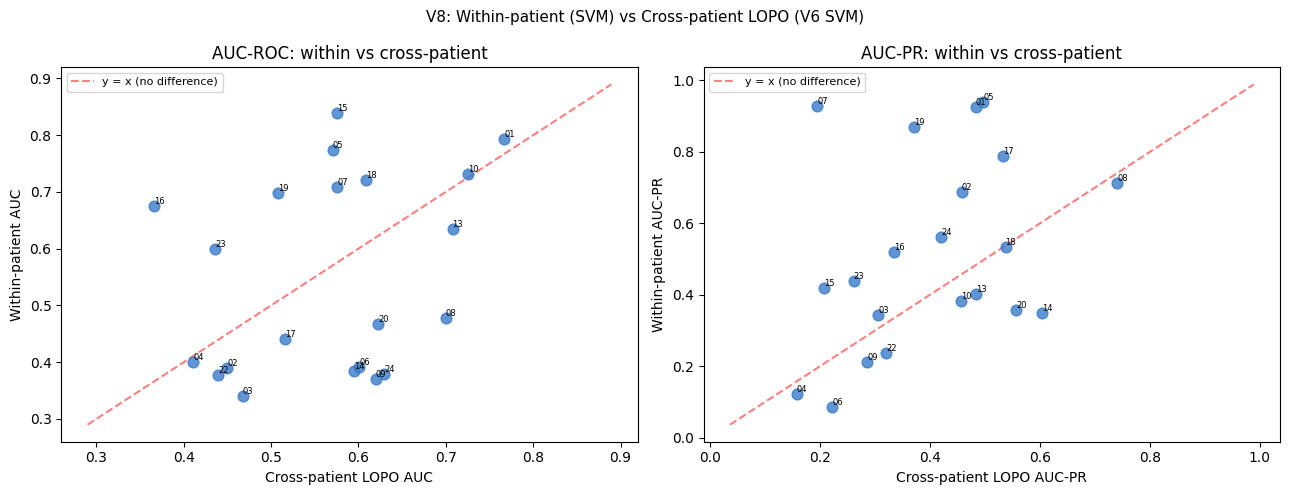

Saved results/v8_within_vs_lopo_scatter.png

Wilcoxon (within > cross-patient):
  AUC:   p=0.6834  not significant at α=0.05
  AUC-PR: p=0.0640  not significant at α=0.05


In [6]:
# Cell 5 — Per-patient AUC scatter: within-patient vs cross-patient LOPO

xp_df = load_csv(os.path.join(RESULTS_DIR, 'lopo_v6_SVM_all_bands.csv'))
wp_df = within_dfs.get('SVM', within_dfs.get('LR'))

if xp_df is not None and wp_df is not None:
    shared = sorted(set(xp_df['patient']) & set(wp_df['patient']))
    xp_auc = xp_df.set_index('patient').loc[shared, 'auc'].astype(float)
    wp_auc = wp_df.set_index('patient').loc[shared, 'auc'].astype(float)
    xp_pr  = xp_df.set_index('patient').loc[shared, 'auc_pr'].astype(float)
    wp_pr  = wp_df.set_index('patient').loc[shared, 'auc_pr'].astype(float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, xvals, yvals, xlab, ylab, title in [
        (axes[0], xp_auc, wp_auc,
         'Cross-patient LOPO AUC', 'Within-patient AUC', 'AUC-ROC'),
        (axes[1], xp_pr,  wp_pr,
         'Cross-patient LOPO AUC-PR', 'Within-patient AUC-PR', 'AUC-PR'),
    ]:
        ax.scatter(xvals, yvals, color='#3a7bc8', alpha=0.8, s=60, zorder=3)
        for pid in shared:
            ax.annotate(pid.replace('chb',''), (xvals[pid], yvals[pid]),
                        fontsize=6, ha='left', va='bottom')
        lims = [min(xvals.min(), yvals.min()) - 0.05,
                max(xvals.max(), yvals.max()) + 0.05]
        ax.plot(lims, lims, 'r--', alpha=0.5, label='y = x (no difference)')
        ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.set_title(f'{title}: within vs cross-patient')
        ax.legend(fontsize=8)

    plt.suptitle('V8: Within-patient (SVM) vs Cross-patient LOPO (V6 SVM)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'v8_within_vs_lopo_scatter.png'), dpi=130)
    plt.show()
    print('Saved results/v8_within_vs_lopo_scatter.png')

    # Wilcoxon test
    try:
        _, p_auc = wilcoxon(wp_auc.values - xp_auc.values,
                            alternative='greater', zero_method='zsplit')
        _, p_pr  = wilcoxon(wp_pr.values  - xp_pr.values,
                            alternative='greater', zero_method='zsplit')
        print(f'\nWilcoxon (within > cross-patient):')
        print(f'  AUC:   p={p_auc:.4f}  {"significant" if p_auc < 0.05 else "not significant"} at α=0.05')
        print(f'  AUC-PR: p={p_pr:.4f}  {"significant" if p_pr  < 0.05 else "not significant"} at α=0.05')
    except ValueError:
        pass


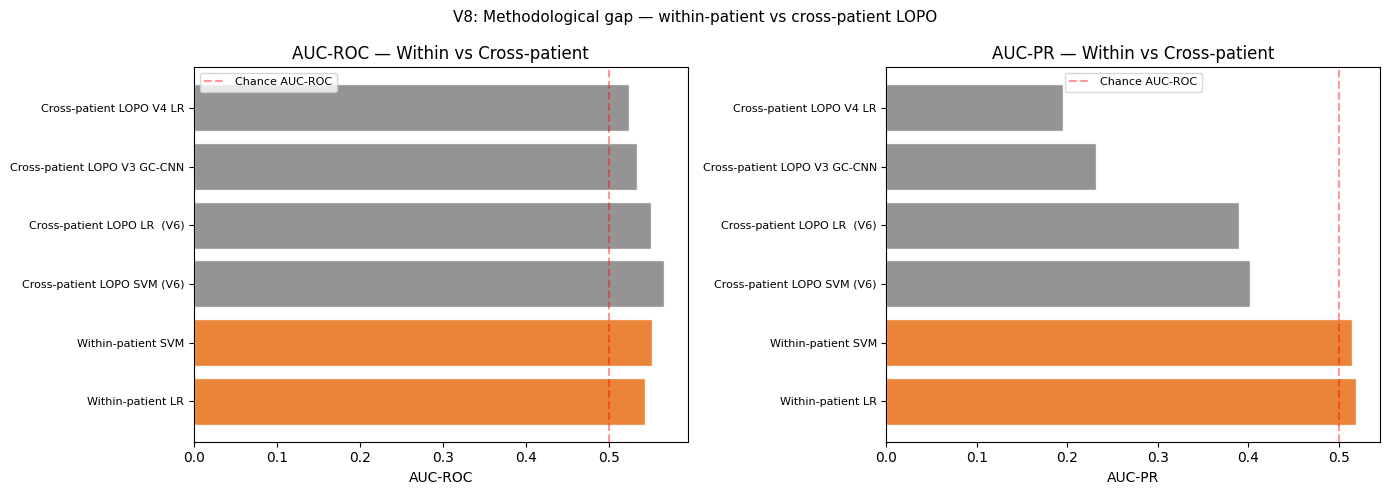

Saved results/v8_protocol_comparison.png


In [7]:
# Cell 6 — Bar chart summary

protocols = []
auc_vals  = []
pr_vals   = []
colors    = []

for _, r in comp_df.iterrows():
    protocols.append(r['protocol'].split('←')[0].strip())
    auc_vals.append(float(r['auc']))
    pr_vals.append(float(r['auc_pr']))
    colors.append('#e87722' if 'Within' in r['protocol'] else '#888')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, title in zip(axes, [auc_vals, pr_vals], ['AUC-ROC', 'AUC-PR']):
    y_pos = range(len(protocols))
    ax.barh(y_pos, vals, color=colors, edgecolor='white', alpha=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(protocols, fontsize=8)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='Chance AUC-ROC')
    ax.set_xlabel(title)
    ax.set_title(f'{title} — Within vs Cross-patient')
    ax.legend(fontsize=8)

plt.suptitle('V8: Methodological gap — within-patient vs cross-patient LOPO', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v8_protocol_comparison.png'), dpi=130)
plt.show()
print('Saved results/v8_protocol_comparison.png')


## 4 · Thesis interpretation

**Expected result**: within-patient AUC substantially higher than cross-patient LOPO.

This directly explains the gap between this thesis and papers reporting AUC > 0.85:
they train and test on the same patient. Our cross-patient LOPO is the harder,
clinically relevant evaluation (a seizure prediction system trained on population
data must generalise to a new patient without any of their recordings).

The within-patient result also quantifies how much of the seizure signal is
**patient-specific** — if within-patient AUC is 0.80 but cross-patient is 0.57,
the majority of the predictive signal is idiosyncratic to each patient,
not a generalizable preictal biomarker.
